Claim 1

### 1. Формализация утверждения

Рассмотрим задачу минимизации суммы двух квадратичных функций, распределенных по двум узлам.

**Определение функций.**
Для $i \in \{1, 2\}$ зададим выпуклые квадратичные функции $f_i: \mathbb{R}^d \to \mathbb{R}$:
$$
f_i(x) = \frac{1}{2} x^\top A_i x - b_i^\top x,
$$
где $A_i \in \mathbb{R}^{d \times d}$ — симметричные положительно определенные матрицы, $b_i \in \mathbb{R}^d$.
Целевая функция определяется как среднее арифметическое:
$$
f(x) = \frac{1}{2} \left( f_1(x) + f_2(x) \right).
$$

**Параметризация.**
Пусть $x_2^* \in \mathbb{R}^d$ — произвольный вектор. Параметры функций фиксируются следующим образом:
1.  $b_2 = A_2 x_2^*$, что подразумевает $\nabla f_2(x_2^*) = 0$, то есть $x_2^* = \arg\min f_2(x)$.
2.  $x_1^* = -A_2^{-1} A_1 x_2^*$.
3.  $b_1 = A_1 x_1^*$, что подразумевает $\nabla f_1(x_1^*) = 0$, то есть $x_1^* = \arg\min f_1(x)$.

**Гипотеза.**
Утверждается, что глобальный минимум $x^* = \arg\min f(x)$ может быть получен суммированием локальных минимумов:
$$
x^* \stackrel{?}{=} \bar{x} = x_1^* + x_2^*.
$$


In [9]:
import numpy as np

def test_quadratic_average(d=5, seed=42):
    np.random.seed(seed)
    
    # Генерация SPD матриц A1, A2
    M1 = np.random.randn(d, d)
    A1 = M1.T @ M1 + np.eye(d)
    M2 = np.random.randn(d, d)
    A2 = M2.T @ M2 + np.eye(d)
    
    # Параметризация согласно утверждению
    x2_star = np.random.randn(d)
    b2 = A2 @ x2_star
    x1_star = -np.linalg.solve(A2, A1 @ x2_star)
    b1 = A1 @ x1_star
    
    # Локальные минимумы (должны совпадать с x1_star, x2_star)
    # Глобальный минимум f = (f1 + f2) / 2
    A_sum = A1 + A2
    b_sum = b1 + b2
    x_true = np.linalg.solve(A_sum, b_sum)
    
    # Усредненное решение
    x_sum = (x1_star + x2_star)
    
    # Оценка ошибки
    error = np.linalg.norm(x_true - x_sum)
    print(f"Norm of difference ||x_true - x_sum||: {error:.6e}")
    return error

if __name__ == "__main__":
    test_quadratic_average()

Norm of difference ||x_true - x_sum||: 9.087567e-16


alpha=0.0033, norm=0.012320796659795578
alpha=0.0067, norm=0.02406636566857733
alpha=0.0100, norm=0.03526351322485792
alpha=0.0134, norm=0.04593745838858252
alpha=0.0167, norm=0.05611194810535448
alpha=0.0201, norm=0.06580936238289613
alpha=0.0234, norm=0.07505081058938722
alpha=0.0268, norm=0.08385621973573397
alpha=0.0301, norm=0.09224441550947367
alpha=0.0334, norm=0.10023319674512798
alpha=0.0368, norm=0.10783940394287005
alpha=0.0401, norm=0.11507898238303213
alpha=0.0435, norm=0.12196704032718214
alpha=0.0468, norm=0.12851790274620573
alpha=0.0502, norm=0.13474516097130554
alpha=0.0535, norm=0.14066171862426824
alpha=0.0569, norm=0.14627983414819903
alpha=0.0602, norm=0.15161116022863316
alpha=0.0635, norm=0.15666678036700646
alpha=0.0669, norm=0.1614572428435594
alpha=0.0702, norm=0.1659925922844505
alpha=0.0736, norm=0.1702823990279028
alpha=0.0769, norm=0.17433578646630882
alpha=0.0803, norm=0.1781614565251578
alpha=0.0836, norm=0.18176771342519735
alpha=0.0870, norm=0.1851624

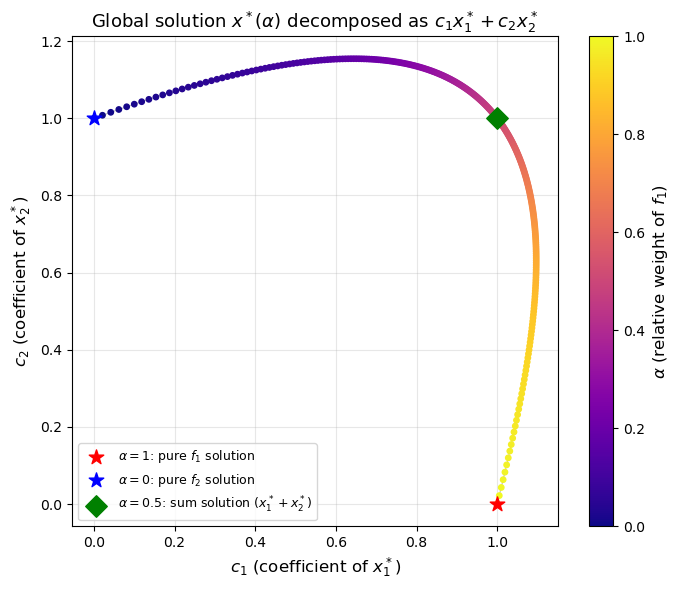

In [14]:
import numpy as np
import matplotlib.pyplot as plt


def setup_problem(d=2, seed=42):
    np.random.seed(seed)
    M1 = np.random.randn(d, d)
    A1 = M1.T @ M1 + np.eye(d)
    M2 = np.random.randn(d, d)
    A2 = M2.T @ M2 + np.eye(d)

    x2_star = np.random.randn(d)
    b2 = A2 @ x2_star
    x1_star = -np.linalg.solve(A2, A1 @ x2_star)
    b1 = A1 @ x1_star

    return A1, A2, b1, b2, x1_star, x2_star


def global_solution(alpha, A1, A2, b1, b2):
    """x*(alpha) = argmin [alpha*f1 + (1-alpha)*f2]"""
    A = alpha * A1 + (1 - alpha) * A2
    b = alpha * b1 + (1 - alpha) * b2
    return np.linalg.solve(A, b)


def decompose(x, x1_star, x2_star, alpha=None):
    """Find c1, c2 such that x = c1*x1_star + c2*x2_star (least-squares if d>2)."""
    B = np.column_stack([x1_star, x2_star])
    coeffs, *_ = np.linalg.lstsq(B, x, rcond=None)
    if alpha:
        print(f"{alpha=:.4f}, norm={np.linalg.norm(x - (x1_star * coeffs[0] + x2_star * coeffs[1]))}")
    return coeffs  # [c1, c2]


A1, A2, b1, b2, x1_star, x2_star = setup_problem(d=4, seed=42)

alphas = np.linspace(0, 1, 300)
c1_vals, c2_vals = [], []

for alpha in alphas:
    x_star = global_solution(alpha, A1, A2, b1, b2)
    c1, c2 = decompose(x_star, x1_star, x2_star, alpha=alpha)
    c1_vals.append(c1)
    c2_vals.append(c2)

c1_vals = np.array(c1_vals)
c2_vals = np.array(c2_vals)

# Verify boundary conditions
print(f"alpha=0: c1={c1_vals[0]:.3f}, c2={c2_vals[0]:.3f}  (expect c1=0, c2=1)")
step = 30
for i in range(step, len(alphas), step):
    print(f"alpha={alphas[i]:.3f}: c1={c1_vals[i]:.3f}, c2={c2_vals[i]:.3f}")
print(f"alpha=1: c1={c1_vals[-1]:.3f}, c2={c2_vals[-1]:.3f}  (expect c1=1, c2=0)")
mid = len(alphas) // 2
print(
    f"alpha=0.5: c1={c1_vals[mid]:.3f}, c2={c2_vals[mid]:.3f}  (expect c1=1, c2=1 since x*=x1*+x2*)"
)

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(c1_vals, c2_vals, c=alphas, cmap="plasma", s=15, zorder=3)
# Draw path line
ax.plot(c1_vals, c2_vals, color="gray", lw=0.8, alpha=0.5, zorder=2)

# Mark key points
ax.scatter(
    *decompose(x1_star, x1_star, x2_star),
    s=120,
    marker="*",
    color="red",
    zorder=5,
    label=r"$\alpha=1$: pure $f_1$ solution",
)
ax.scatter(
    *decompose(x2_star, x1_star, x2_star),
    s=120,
    marker="*",
    color="blue",
    zorder=5,
    label=r"$\alpha=0$: pure $f_2$ solution",
)
ax.scatter(
    *decompose(x1_star + x2_star, x1_star, x2_star),
    s=120,
    marker="D",
    color="green",
    zorder=5,
    label=r"$\alpha=0.5$: sum solution $(x_1^*+x_2^*)$",
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$\alpha$ (relative weight of $f_1$)", fontsize=12)

ax.set_xlabel(r"$c_1$ (coefficient of $x_1^*$)", fontsize=12)
ax.set_ylabel(r"$c_2$ (coefficient of $x_2^*$)", fontsize=12)
ax.set_title(
    r"Global solution $x^*(\alpha)$ decomposed as $c_1 x_1^* + c_2 x_2^*$", fontsize=13
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

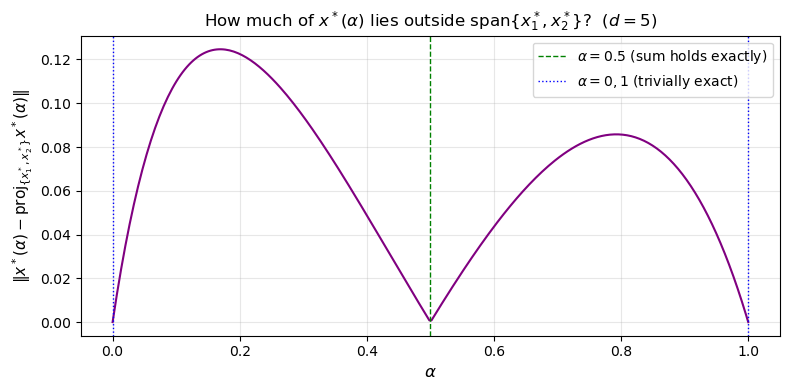

Residual at alpha=0.0: 2.54e-16
Residual at alpha=0.5: 7.93e-04
Residual at alpha=1.0: 5.87e-16
Max residual at: alpha=0.171, value=0.1247


In [16]:
A1, A2, b1, b2, x1_star, x2_star = setup_problem(d=5, seed=42)

alphas = np.linspace(0, 1, 300)
residual_norms = []
residuals = []

for alpha in alphas:
    x_star = global_solution(alpha, A1, A2, b1, b2)
    B = np.column_stack([x1_star, x2_star])
    coeffs, *_ = np.linalg.lstsq(B, x_star, rcond=None)
    projection = B @ coeffs
    residual_norms.append(np.linalg.norm(x_star - projection))
    residuals.append(x_star - projection)

residual_norms = np.array(residual_norms)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, residual_norms, color="purple", lw=1.5)
ax.axvline(0.5, color="green", linestyle="--", lw=1, label=r"$\alpha=0.5$ (sum holds exactly)")
ax.axvline(0.0, color="blue", linestyle=":", lw=1, label=r"$\alpha=0,1$ (trivially exact)")
ax.axvline(1.0, color="blue", linestyle=":", lw=1)
ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_ylabel(r"$\|x^*(\alpha) - \mathrm{proj}_{\{x_1^*, x_2^*\}} x^*(\alpha)\|$", fontsize=11)
ax.set_title(r"How much of $x^*(\alpha)$ lies outside span$\{x_1^*, x_2^*\}$?  ($d=5$)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Residual at alpha=0.0: {residual_norms[0]:.2e}")
print(f"Residual at alpha=0.5: {residual_norms[len(alphas)//2]:.2e}")
print(f"Residual at alpha=1.0: {residual_norms[-1]:.2e}")
print(f"Max residual at: alpha={alphas[residual_norms.argmax()]:.3f}, value={residual_norms.max():.4f}")


In [17]:
residuals = np.array(residuals)
residuals

array([[-5.55111512e-17,  1.11022302e-16,  0.00000000e+00,
         0.00000000e+00, -2.22044605e-16],
       [ 5.76308436e-03,  1.33220404e-03, -9.71336103e-04,
         4.73868381e-04, -2.23287001e-03],
       [ 1.12993615e-02,  2.60784459e-03, -1.90439427e-03,
         9.30342102e-04, -4.38012015e-03],
       ...,
       [-5.83606181e-03, -2.05531056e-04, -1.16002013e-04,
        -1.10533025e-03,  2.33735093e-03],
       [-2.95587243e-03, -9.87376129e-05, -6.79900156e-05,
        -5.63811280e-04,  1.18212937e-03],
       [ 2.22044605e-16, -2.22044605e-16, -4.44089210e-16,
         0.00000000e+00, -2.22044605e-16]], shape=(300, 5))

In [32]:
res_S = np.linalg.svd(residuals).S
print(f"{res_S}")

[1.31321749e+00 7.93757930e-02 9.72453493e-03 1.12490772e-14
 4.14044379e-15]


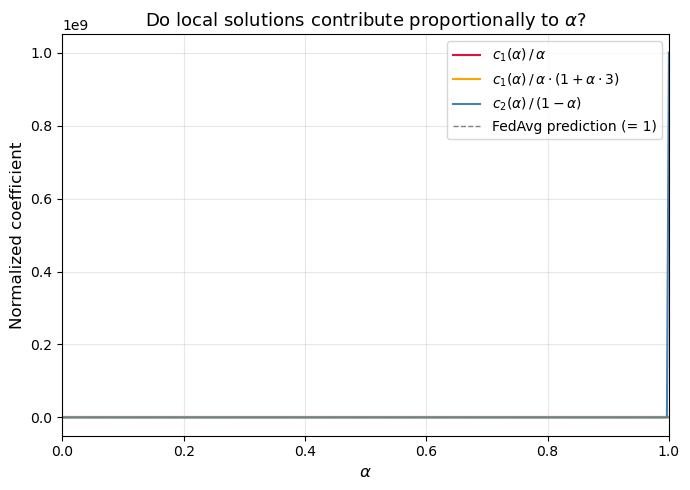

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

# Avoid division by zero at endpoints
eps = 1e-9
c1_norm = c1_vals / np.clip(alphas, eps, 1)
c1_norm_special = c1_vals / np.clip(alphas, eps, 1) * (1 + alphas * 3)
c2_norm = c2_vals / np.clip(1 - alphas, eps, 1)

ax.plot(alphas, c1_norm, label=r"$c_1(\alpha)\,/\,\alpha$", color="crimson")
ax.plot(alphas, c1_norm_special, label=r"$c_1(\alpha)\,/\,\alpha \cdot (1 + \alpha \cdot 3)$", color="orange")
ax.plot(alphas, c2_norm, label=r"$c_2(\alpha)\,/\,(1-\alpha)$", color="steelblue")
ax.axhline(1.0, color="gray", linestyle="--", lw=1, label="FedAvg prediction (= 1)")

ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_ylabel("Normalized coefficient", fontsize=12)
ax.set_title(r"Do local solutions contribute proportionally to $\alpha$?", fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


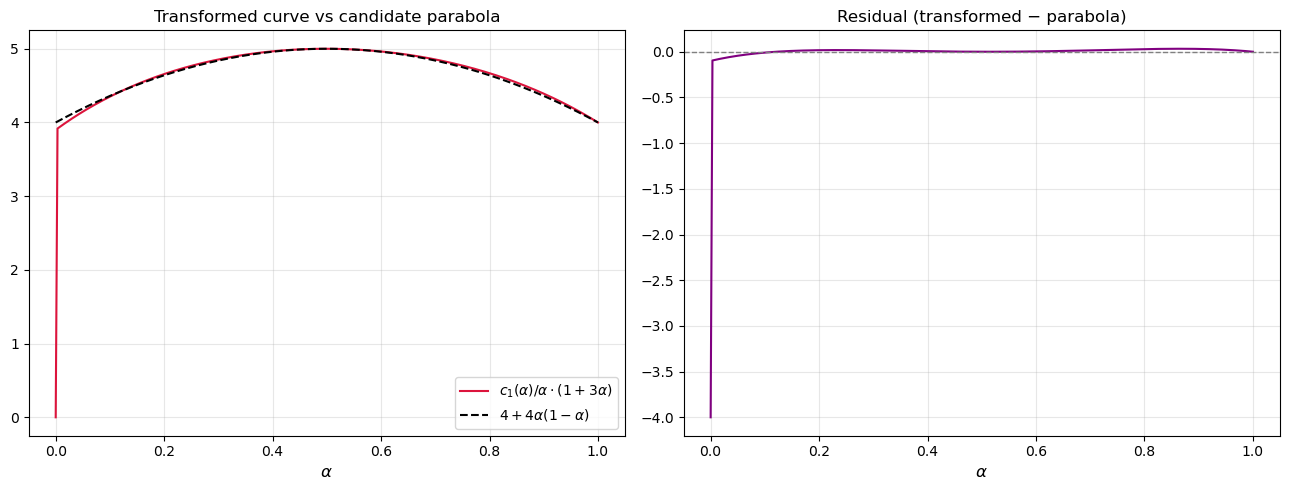

Max absolute residual: 4.000000e+00
Transformed at alpha=0:   -0.000000  (parabola: 4.000000)
Transformed at alpha=0.5: 4.999969  (parabola: 4.999989)
Transformed at alpha=1:   4.000000  (parabola: 4.000000)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

transformed = c1_norm * (1 + 3 * alphas)

# Candidate parabola: endpoints at 4, peak at 5 => p(a) = 4 + 4*a*(1-a)
parabola = 4 + 4 * alphas * (1 - alphas)

axes[0].plot(alphas, transformed, label=r"$c_1(\alpha)/\alpha \cdot (1 + 3\alpha)$", color="crimson")
axes[0].plot(alphas, parabola, "--", color="black", label=r"$4 + 4\alpha(1-\alpha)$")
axes[0].set_xlabel(r"$\alpha$", fontsize=12)
axes[0].set_title("Transformed curve vs candidate parabola", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

residual = transformed - parabola
axes[1].plot(alphas, residual, color="purple")
axes[1].axhline(0, color="gray", linestyle="--", lw=1)
axes[1].set_xlabel(r"$\alpha$", fontsize=12)
axes[1].set_title("Residual (transformed − parabola)", fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max absolute residual: {np.abs(residual).max():.6e}")
print(f"Transformed at alpha=0:   {transformed[0]:.6f}  (parabola: {parabola[0]:.6f})")
print(f"Transformed at alpha=0.5: {transformed[len(alphas)//2]:.6f}  (parabola: {parabola[len(alphas)//2]:.6f})")
print(f"Transformed at alpha=1:   {transformed[-1]:.6f}  (parabola: {parabola[-1]:.6f})")
